In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

In [102]:
tor = pd.concat([pd.read_csv(f"../merged/merged_tornados_{i}.csv.gz") for i in range(2023, 2014, -1)], axis=0)

In [103]:
tor.info()

<class 'pandas.core.frame.DataFrame'>
Index: 346371 entries, 0 to 25393
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            346371 non-null  int64  
 1   DATE                  346371 non-null  object 
 2   LAT_mean              346371 non-null  float64
 3   LON_mean              346371 non-null  float64
 4   AVGDV_max             346371 non-null  int64  
 5   LLDV_max              346371 non-null  int64  
 6   MXDV_max              346371 non-null  int64  
 7   MXDV_HEIGHT_max       346371 non-null  int64  
 8   DEPTH_max             346371 non-null  float64
 9   MAX_SHEAR_max         346371 non-null  int64  
 10  MAX_SHEAR_HEIGHT_max  346371 non-null  float64
 11  county                346371 non-null  object 
 12  state                 346371 non-null  object 
 13  Event Month           7272 non-null    object 
 14  power_outage          346371 non-null  bool   
 15  Month 

In [104]:
# Deletes the column named 'Unnamed: 0' from the DataFrame tor
del tor['Unnamed: 0']
#Converts the values in the 'DATE' column of the DataFrame tor to datetime objects
tor['DATE'] = pd.to_datetime(tor['DATE'])
# Extracts the month component from the datetime values in the 'DATE' column and assigns it to a new column named 'Month' in the DataFrame tor
tor['Month'] = tor['DATE'].dt.month

In [105]:
tor.columns

Index(['DATE', 'LAT_mean', 'LON_mean', 'AVGDV_max', 'LLDV_max', 'MXDV_max',
       'MXDV_HEIGHT_max', 'DEPTH_max', 'MAX_SHEAR_max', 'MAX_SHEAR_HEIGHT_max',
       'county', 'state', 'Event Month', 'power_outage', 'Month'],
      dtype='object')

Logistic Regression

In [106]:
tor.power_outage.value_counts(normalize=True)

power_outage
False    0.951875
True     0.048125
Name: proportion, dtype: float64

In [107]:
tor['y'] = tor['power_outage'].astype(int)

In [108]:
tor.y.value_counts(normalize=True)

y
0    0.951875
1    0.048125
Name: proportion, dtype: float64

In [109]:
tor_train, tor_test = train_test_split(tor.copy(),
                                              shuffle=True,
                                              random_state=123,
                                              test_size=.2,
                                              stratify=tor.y.values)


In [110]:
tor_tt, tor_val = train_test_split(tor_train.copy(),
                                              shuffle=True,
                                              random_state=123,
                                              test_size=.2,
                                              stratify=tor_train.y.values)

In [111]:
outage = tor_tt[tor_tt['power_outage']==True]
no_outage = tor_tt[tor_tt['power_outage']==False]
no_outage= no_outage.sample(n=len(outage), random_state=101)
tor_tt_bal = pd.concat([outage,no_outage],axis=0)


In [112]:
n_splits = 5

kfold = StratifiedKFold(n_splits,
                           shuffle=True,
                           random_state=498)

In [113]:
tor_tt_bal.columns

Index(['DATE', 'LAT_mean', 'LON_mean', 'AVGDV_max', 'LLDV_max', 'MXDV_max',
       'MXDV_HEIGHT_max', 'DEPTH_max', 'MAX_SHEAR_max', 'MAX_SHEAR_HEIGHT_max',
       'county', 'state', 'Event Month', 'power_outage', 'Month', 'y'],
      dtype='object')

In [114]:
all_features= ['LAT_mean', 'LON_mean', 'AVGDV_max', 'LLDV_max', 'MXDV_max',
       'MXDV_HEIGHT_max', 'DEPTH_max', 'MAX_SHEAR_max', 'MAX_SHEAR_HEIGHT_max','Month']

In [115]:

#logistic regression with all the features 
log_accs = np.zeros((n_splits, len(all_features)))
log_precs = np.zeros((n_splits, len(all_features)))
log_recs = np.zeros((n_splits, len(all_features)))

i = 0
for train_index, test_index in kfold.split(tor_tt_bal, tor_tt_bal.y):
    tor_tt_tt = tor_tt_bal.iloc[train_index]
    tor_ho = tor_tt_bal.iloc[test_index]
    
    j = 0
    for feature in all_features:
        log_reg = LogisticRegression(penalty=None)
        
        log_reg.fit(tor_tt_tt[all_features],
                       tor_tt_tt.y.values)
        
        pred = log_reg.predict(tor_ho[all_features])
        
        log_accs[i,j]=accuracy_score(tor_ho.y.values,
                                              pred)
        log_precs[i,j]=precision_score(tor_ho.y.values,
                                              pred)
        log_recs[i,j] = recall_score(tor_ho.y.values,
                                              pred)
        
        j = j + 1
    i = i + 1

c:\Users\Hatice\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Hatice\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

In [116]:
mean_accs= np.mean(log_accs)
mean_precs= np.mean(log_precs)
mean_recs= np.mean(log_recs)

In [117]:
print('Mean of accuracy is', mean_accs)
print('Mean of precision is', mean_precs)
print('Mean of recall is', mean_recs)

Mean of accuracy is 0.5888166502631627
Mean of precision is 0.5840947603638975
Mean of recall is 0.6156676601150045


KNN

In [118]:
# knn for all the features
ks = range(1,56)


k_all_accs = np.zeros((5, len(ks)))
k_all_recs = np.zeros((5, len(ks))) 
k_all_precis = np.zeros((5, len(ks))) 

i = 0
for train_index, test_index in kfold.split(tor_tt_bal, tor_tt_bal.y):
    tor_bal_tt = tor_tt_bal.iloc[train_index]
    tor_ho = tor_tt_bal.iloc[test_index]
    
    j = 0
    for k in ks:
        knn = Pipeline([('scale', StandardScaler()),('knn_cls', KNeighborsClassifier(k))])
        
        knn.fit(tor_bal_tt[all_features].values,
                   tor_bal_tt.y.values)
        
        pred = knn.predict(tor_ho[all_features].values)
        
        k_all_accs[i,j] = accuracy_score(tor_ho.y.values, pred)

        k_all_recs[i] = recall_score(tor_ho.y.values,
                                              pred)
        
        k_all_precis[i] = precision_score(tor_ho.y.values,
                                              pred)
        
        j = j + 1
    i = i + 1

In [119]:
mean_k_all_accs= np.mean(k_all_accs)
mean_k_all_precs= np.mean(k_all_precis)
mean_k_all_recs= np.mean(k_all_recs)

In [120]:
print('Mean of accuracy is', mean_k_all_accs)
print('Mean of precision is', mean_k_all_precs)
print('Mean of recall is', mean_k_all_recs)

Mean of accuracy is 0.6671873185655005
Mean of precision is 0.6502374978893648
Mean of recall is 0.7130668554262447


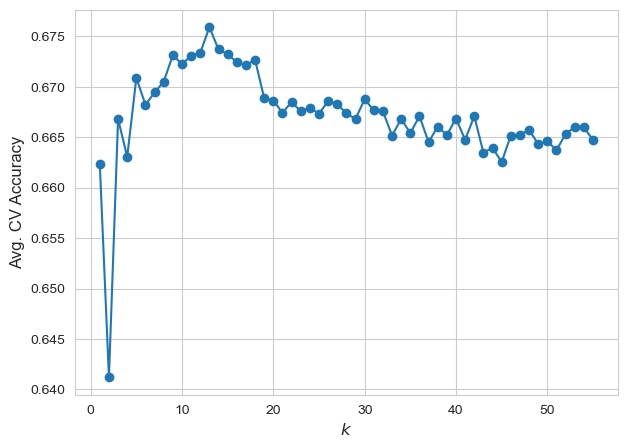

In [121]:
plt.figure(figsize=(7,5))


plt.plot(ks, 
         np.mean(k_all_accs, axis=0),
         '-o')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("$k$", fontsize=12)
plt.ylabel("Avg. CV Accuracy", fontsize=12)

plt.show()

In [122]:
best_k = np.argmax(np.mean(k_all_accs, axis=0))
best_k_acc = np.mean(k_all_accs, axis=0)[best_k]

print("The optimal value of k was", best_k + 1, "which achieved a mean CV accuracy of ", best_k_acc)

The optimal value of k was 13 which achieved a mean CV accuracy of  0.675899763864219


In [123]:
knn_best = KNeighborsClassifier(n_neighbors=10)

In [124]:
knn_best.fit(tor_tt_bal[all_features].values,
                   tor_tt_bal.y.values)

pred_best = knn_best.predict(tor_val[all_features].values)

In [125]:
print("accuracy score:", accuracy_score(tor_val.y.values, pred_best))
print("recall score:", recall_score(tor_val.y.values, pred_best))
print("precision score:", precision_score(tor_val.y.values, pred_best))

accuracy score: 0.6577408877661494
recall score: 0.5620547431571054
precision score: 0.07767241826001348
